# 08 - Vision-to-imagery transfer across visual and parietal cortex

This notebook tests a collaborator-inspired idea: target information seen during perception may appear in a transformed form in parietal cortex during imagery. It keeps two analyses separate.

1. **Primary, dimension-free RSA:** compare the target geometry of visual-cortex vision with visual-cortex imagery and parietal-cortex imagery.
2. **Secondary aligned decoder:** learn a parietal-to-visual mapping from **Set C vision only**, freeze it, and test A/B imagery. No tested imagery beta is used to fit PCA, alignment weights, or hyperparameters.

This is an exploratory analysis suggested after earlier results were inspected. Subject 01 remains the pilot; subjects 02--08 provide a less selected validation summary.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'nsdimagery').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'nsdimagery').is_dir():
    raise RuntimeError('Start Jupyter from the repository root or notebooks/.')
sys.path.insert(0, str(REPO_ROOT))

from nsdimagery import STREAM_ROI_LABELS, find_data_root

sns.set_theme(style='whitegrid', context='notebook')
DATA_ROOT = find_data_root(REPO_ROOT)
OUTPUT_DIR = REPO_ROOT / 'outputs' / '08_cross_region_transfer'
FIGURE_DIR = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('Python:', sys.version.split()[0])
print('Repository:', REPO_ROOT)
print('Data root:', DATA_ROOT)
print('Output:', OUTPUT_DIR)

Python: 3.12.13
Repository: /home/jovyan/NHprojectNSDimagery
Data root: /home/jovyan/NHprojectNSDimagery/data/nsd
Output: /home/jovyan/NHprojectNSDimagery/outputs/08_cross_region_transfer


## 1. Predeclared regions and contrasts

The primary regions are disjoint parts of the NSD `streams` atlas:

- `visual_streams`: early, midventral, midlateral, ventral, and lateral labels (1, 2, 3, 5, 6);
- `dorsal_parietal`: midparietal and parietal labels (4, 7).

For subject $s$, let $D^{V}_{s,r}$ and $D^{I}_{s,r}$ be vision and imagery target RDMs in region $r$. The planned comparison is

$$
\Delta_s =
\rho\!\left(D^V_{s,\mathrm{visual}},D^I_{s,\mathrm{parietal}}\right)
-
\rho\!\left(D^V_{s,\mathrm{visual}},D^I_{s,\mathrm{visual}}\right).
$$

A positive $\Delta_s$ matches the collaborator's proposed pattern. It does not by itself identify a neural transformation, so within-parietal transfer, reverse-direction transfer, RDM reliability, crossvalidated RDMs, and leave-one-target sensitivity are also reported.

In [2]:
roi_table = pd.DataFrame([
    {'roi': name, 'stream_labels': ', '.join(map(str, labels))}
    for name, labels in STREAM_ROI_LABELS.items()
])
display(roi_table)

SUBJECTS = '1-8'
MAX_VOXELS = 1200
N_RDM_SPLITS = 100
N_ALIGNMENT_PERMUTATIONS = 100
BASE_SEED = 2026
RUN_ANALYSIS = True

analysis_command = [
    sys.executable,
    str(REPO_ROOT / 'scripts' / 'run_cross_region_transfer.py'),
    '--data-root', str(DATA_ROOT),
    '--subjects', SUBJECTS,
    '--output-dir', str(OUTPUT_DIR),
    '--max-voxels', str(MAX_VOXELS),
    '--n-rdm-splits', str(N_RDM_SPLITS),
    '--n-alignment-permutations', str(N_ALIGNMENT_PERMUTATIONS),
    '--seed', str(BASE_SEED),
]
print(' '.join(analysis_command))
if RUN_ANALYSIS:
    subprocess.run(analysis_command, check=True)
else:
    print('Set RUN_ANALYSIS=True to compute or refresh the result tables.')

,roi,stream_labels
0,early,1
1,midventral,2
2,midlateral,3
3,midparietal,4
4,ventral,5
5,lateral,6
6,parietal,7
7,visual_streams,"1, 2, 3, 5, 6"
8,dorsal_parietal,"4, 7"


/srv/conda/envs/nsdimagery/bin/python /home/jovyan/NHprojectNSDimagery/scripts/run_cross_region_transfer.py --data-root /home/jovyan/NHprojectNSDimagery/data/nsd --subjects 1-8 --output-dir /home/jovyan/NHprojectNSDimagery/outputs/08_cross_region_transfer --max-voxels 1200 --n-rdm-splits 100 --n-alignment-permutations 100 --seed 2026

subj01
  early: 1200 / 5917 voxels (extracted)
  ventral: 1200 / 7604 voxels (extracted)
  lateral: 1200 / 7799 voxels (extracted)
  midparietal: 950 / 950 voxels (extracted)
  parietal: 1200 / 3548 voxels (extracted)
  visual_streams: 1200 / 23140 voxels (extracted)
  dorsal_parietal: 1200 / 4498 voxels (extracted)

subj02
  early: 1200 / 4611 voxels (extracted)
  ventral: 1200 / 8185 voxels (extracted)
  lateral: 1200 / 6752 voxels (extracted)
  midparietal: 822 / 822 voxels (extracted)
  parietal: 1200 / 3355 voxels (extracted)
  visual_streams: 1200 / 21040 voxels (extracted)
  dorsal_parietal: 1200 / 4177 voxels (extracted)

subj03
  early: 1200 / 51

## 2. Primary RDM result

`standard_rho` compares ordinary correlation-distance RDMs from all repeats. `crossvalidated_rho` compares repeat-independent dot-product RDM estimates. Agreement between them is more convincing than either result alone.

In [3]:
required = {
    'planned': OUTPUT_DIR / 'planned_rdm_comparisons.csv',
    'contrast': OUTPUT_DIR / 'rdm_contrasts_subject_level.csv',
    'group': OUTPUT_DIR / 'rdm_group_summary.csv',
    'contrast_group': OUTPUT_DIR / 'rdm_contrasts_group.csv',
    'transfer': OUTPUT_DIR / 'rdm_transfer_subject_level.csv',
    'reliability': OUTPUT_DIR / 'roi_reliability.csv',
    'counts': OUTPUT_DIR / 'stream_roi_counts.csv',
}
missing = [str(path) for path in required.values() if not path.is_file()]
if missing:
    raise FileNotFoundError('Run the analysis cell first. Missing:\n' + '\n'.join(missing))

planned = pd.read_csv(required['planned'])
contrasts = pd.read_csv(required['contrast'])
rdm_group = pd.read_csv(required['group'])
contrast_group = pd.read_csv(required['contrast_group'])
transfer = pd.read_csv(required['transfer'])
reliability = pd.read_csv(required['reliability'])
roi_counts = pd.read_csv(required['counts'])

primary_group = rdm_group[
    rdm_group['sample'].eq('subjects_02_08')
    & rdm_group['comparison'].isin(['same_visual', 'cross_visual_to_parietal'])
].sort_values(['metric', 'stimulus_set', 'comparison'])
primary_contrast = contrast_group[
    contrast_group['sample'].eq('subjects_02_08')
    & contrast_group['contrast'].eq('cross_minus_same_visual')
].sort_values(['metric', 'stimulus_set'])

display(primary_group)
display(primary_contrast)
display(roi_counts.groupby('roi')[['available_voxels', 'used_voxels']].agg(['min', 'median', 'max']))

,sample,stimulus_set,comparison,metric,n_subjects,mean,median,p_greater,p_two_sided
38,subjects_02_08,A,cross_visual_to_parietal,crossvalidated_rho,7,0.078571,0.075000,0.210938,0.421875
36,subjects_02_08,A,same_visual,crossvalidated_rho,7,-0.015816,-0.057143,0.578125,0.875000
44,subjects_02_08,A+B average,cross_visual_to_parietal,crossvalidated_rho,7,0.050510,-0.042857,0.257812,0.515625
46,subjects_02_08,A+B average,same_visual,crossvalidated_rho,7,0.026786,0.080357,0.359375,0.718750
39,subjects_02_08,B,cross_visual_to_parietal,crossvalidated_rho,7,0.022449,0.082143,0.445312,0.890625
37,subjects_02_08,B,same_visual,crossvalidated_rho,7,0.069388,0.167857,0.281250,0.562500
14,subjects_02_08,A,cross_visual_to_parietal,standard_rho,7,0.398469,0.525000,0.015625,0.031250
12,subjects_02_08,A,same_visual,standard_rho,7,0.479592,0.507143,0.007812,0.015625
20,subjects_02_08,A+B average,cross_visual_to_parietal,standard_rho,7,0.353061,0.408929,0.007812,0.015625
22,subjects_02_08,A+B average,same_visual,standard_rho,7,0.449745,0.451786,0.007812,0.015625


,sample,stimulus_set,contrast,metric,n_subjects,mean,median,p_greater,p_two_sided
27,subjects_02_08,A,cross_minus_same_visual,crossvalidated_difference,7,0.094388,0.103571,0.132812,0.265625
33,subjects_02_08,A+B average,cross_minus_same_visual,crossvalidated_difference,7,0.023724,0.012500,0.375000,0.750000
30,subjects_02_08,B,cross_minus_same_visual,crossvalidated_difference,7,-0.046939,-0.110714,0.664062,0.687500
9,subjects_02_08,A,cross_minus_same_visual,standard_difference,7,-0.081122,0.010714,0.773438,0.468750
15,subjects_02_08,A+B average,cross_minus_same_visual,standard_difference,7,-0.096684,-0.125000,0.945312,0.140625
12,subjects_02_08,B,cross_minus_same_visual,standard_difference,7,-0.112245,-0.085714,0.906250,0.218750


available_voxels                 used_voxels              
                             min   median    max         min  median   max
roi                                                                       
dorsal_parietal             3151   4110.5   4711        1200  1200.0  1200
early                       4054   4603.5   5917        1200  1200.0  1200
lateral                     6118   7465.0   9030        1200  1200.0  1200
midparietal                  653    760.0    950         653   760.0   950
parietal                    2459   3364.5   3885        1200  1200.0  1200
ventral                     6515   7906.0   9666        1200  1200.0  1200
visual_streams             18605  22090.0  26832        1200  1200.0  1200

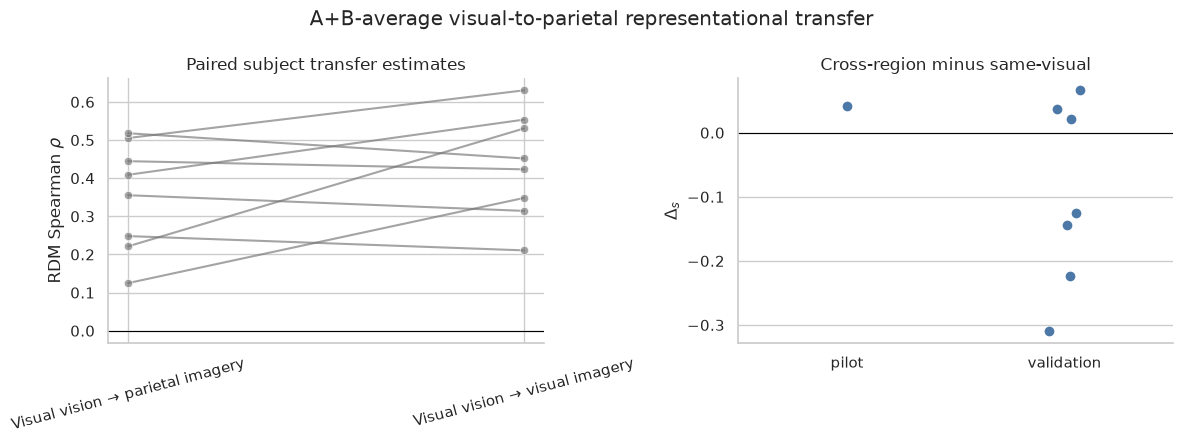

Saved: /home/jovyan/NHprojectNSDimagery/outputs/08_cross_region_transfer/figures/primary_cross_region_rdm.png


In [4]:
comparison_labels = {
    'same_visual': 'Visual vision → visual imagery',
    'cross_visual_to_parietal': 'Visual vision → parietal imagery',
}
plot_frame = planned[
    planned['stimulus_set'].eq('A+B average')
    & planned['comparison'].isin(comparison_labels)
].copy()
plot_frame['comparison_label'] = plot_frame['comparison'].map(comparison_labels)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(
    data=plot_frame, x='comparison_label', y='standard_rho',
    units='subject', estimator=None, marker='o', alpha=.65, color='0.45', ax=axes[0],
)
sns.stripplot(
    data=contrasts[
        contrasts['stimulus_set'].eq('A+B average')
        & contrasts['contrast'].eq('cross_minus_same_visual')
    ],
    x='phase', y='standard_difference', order=['pilot', 'validation'],
    color='#4C78A8', size=7, jitter=.08, ax=axes[1],
)
axes[0].axhline(0, color='black', linewidth=.8)
axes[1].axhline(0, color='black', linewidth=.8)
axes[0].set(title='Paired subject transfer estimates', xlabel='', ylabel='RDM Spearman $\\rho$')
axes[0].tick_params(axis='x', rotation=15)
axes[1].set(title='Cross-region minus same-visual', xlabel='', ylabel='$\\Delta_s$')
for axis in axes:
    axis.spines[['top', 'right']].set_visible(False)
figure.suptitle('A+B-average visual-to-parietal representational transfer')
figure.tight_layout()
primary_plot = FIGURE_DIR / 'primary_cross_region_rdm.png'
figure.savefig(primary_plot, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved:', primary_plot)

## 3. Full cross-region matrix and reliability

The matrix is descriptive. The planned contrast above remains the main statistic. Atomic stream ROIs are shown to reveal whether an effect is localized to midparietal, superior parietal, ventral, or lateral cortex.

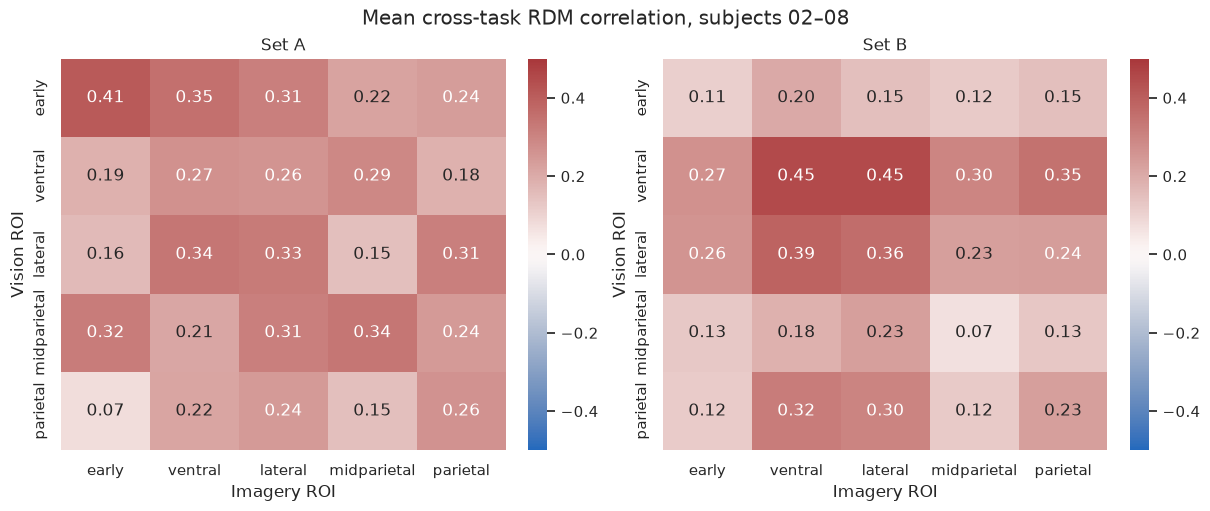

Saved: /home/jovyan/NHprojectNSDimagery/outputs/08_cross_region_transfer/figures/cross_region_rdm_matrix.png


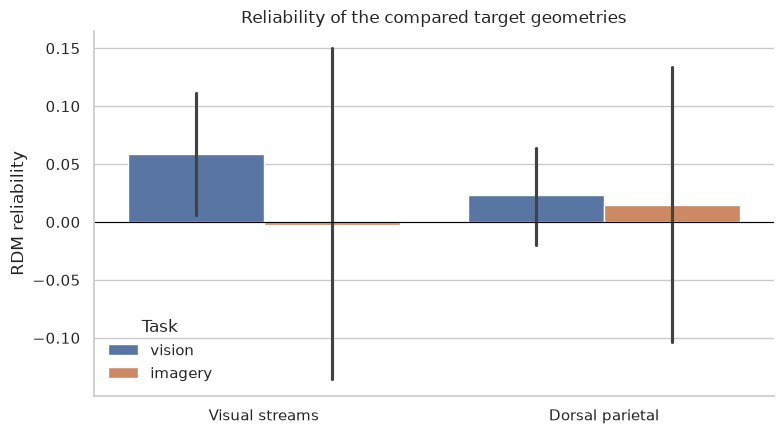

Saved: /home/jovyan/NHprojectNSDimagery/outputs/08_cross_region_transfer/figures/cross_region_reliability.png


In [5]:
atomic_order = ['early', 'ventral', 'lateral', 'midparietal', 'parietal']
matrix_frame = transfer[
    transfer['phase'].eq('validation')
    & transfer['source_vision_roi'].isin(atomic_order)
    & transfer['target_imagery_roi'].isin(atomic_order)
]
figure, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for axis, stimulus_set in zip(axes, ['A', 'B']):
    matrix = (
        matrix_frame[matrix_frame['stimulus_set'].eq(stimulus_set)]
        .groupby(['source_vision_roi', 'target_imagery_roi'])['standard_rho'].mean()
        .unstack()
        .reindex(index=atomic_order, columns=atomic_order)
    )
    sns.heatmap(matrix, vmin=-.5, vmax=.5, center=0, cmap='vlag', annot=True, fmt='.2f', ax=axis)
    axis.set(title=f'Set {stimulus_set}', xlabel='Imagery ROI', ylabel='Vision ROI')
figure.suptitle('Mean cross-task RDM correlation, subjects 02–08')
matrix_plot = FIGURE_DIR / 'cross_region_rdm_matrix.png'
figure.savefig(matrix_plot, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved:', matrix_plot)

reliability_plot_frame = reliability[
    reliability['phase'].eq('validation')
    & reliability['roi'].isin(['visual_streams', 'dorsal_parietal'])
].copy()
figure, axis = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=reliability_plot_frame, x='roi', y='rdm_reliability',
    hue='task', errorbar=('ci', 95), ax=axis,
)
axis.axhline(0, color='black', linewidth=.8)
axis.set(xlabel='', ylabel='RDM reliability', title='Reliability of the compared target geometries')
axis.set_xticks([0, 1], ['Visual streams', 'Dorsal parietal'])
axis.spines[['top', 'right']].set_visible(False)
axis.legend(title='Task', frameon=False)
figure.tight_layout()
reliability_plot = FIGURE_DIR / 'cross_region_reliability.png'
figure.savefig(reliability_plot, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved:', reliability_plot)

## 4. Secondary Set-C-trained alignment decoder

For Set C vision trials, let $P_C$ and $V_C$ be parietal and visual beta patterns. PCA and ridge are selected by leave-one-Set-C-target-out cross-validation:

$$
\widehat A
=
\arg\min_A
\|Z^V_C-Z^P_CA\|_F^2+\lambda\|A\|_F^2.
$$

The fitted map is frozen. For Sets A and B, a six-way centroid decoder is trained on visual-region **vision** patterns. It is tested on (i) visual imagery, (ii) parietal imagery mapped into visual latent space, and (iii) a separate within-parietal baseline. A shuffled Set-C pairing provides a map-specific null.

This tests cross-condition identification of the six known targets. It is not decoding of unseen target identities.

,sample,stimulus_set,decoder,metric,n_subjects,mean,median,p_greater,p_two_sided
9,subjects_02_08,A,same_visual,accuracy_above_chance,7,0.019345,0.010417,0.187500,0.375000
10,subjects_02_08,A,aligned_parietal_to_visual,accuracy_above_chance,7,0.022321,0.020833,0.046875,0.093750
11,subjects_02_08,A,within_parietal,accuracy_above_chance,7,0.046131,0.052083,0.031250,0.062500
12,subjects_02_08,B,same_visual,accuracy_above_chance,7,0.019345,0.020833,0.062500,0.125000
13,subjects_02_08,B,aligned_parietal_to_visual,accuracy_above_chance,7,0.010417,0.000000,0.250000,0.500000
14,subjects_02_08,B,within_parietal,accuracy_above_chance,7,0.034226,0.020833,0.078125,0.156250
15,subjects_02_08,A+B average,aligned_parietal_to_visual,accuracy_above_chance,7,0.016369,0.015625,0.093750,0.187500
16,subjects_02_08,A+B average,same_visual,accuracy_above_chance,7,0.019345,0.020833,0.031250,0.062500
17,subjects_02_08,A+B average,within_parietal,accuracy_above_chance,7,0.040179,0.031250,0.007812,0.015625


,sample,stimulus_set,contrast,metric,n_subjects,mean,median,p_greater,p_two_sided
9,subjects_02_08,A,aligned_minus_same_visual,accuracy_difference,7,0.002976,0.000000,0.453125,0.906250
10,subjects_02_08,A,aligned_minus_within_parietal,accuracy_difference,7,-0.023810,-0.020833,0.984375,0.156250
11,subjects_02_08,A,within_parietal_minus_same_visual,accuracy_difference,7,0.026786,0.020833,0.046875,0.093750
12,subjects_02_08,B,aligned_minus_same_visual,accuracy_difference,7,-0.008929,0.000000,0.937500,0.250000
13,subjects_02_08,B,aligned_minus_within_parietal,accuracy_difference,7,-0.023810,-0.020833,0.796875,0.468750
14,subjects_02_08,B,within_parietal_minus_same_visual,accuracy_difference,7,0.014881,0.010417,0.289062,0.578125
15,subjects_02_08,A+B average,aligned_minus_same_visual,accuracy_difference,7,-0.002976,-0.005208,0.695312,0.765625
16,subjects_02_08,A+B average,aligned_minus_within_parietal,accuracy_difference,7,-0.023810,-0.020833,0.968750,0.078125
17,subjects_02_08,A+B average,within_parietal_minus_same_visual,accuracy_difference,7,0.020833,0.015625,0.007812,0.015625


,subject,phase,n_components,alpha,mean_cv_r2,median_cv_r2,selected
10,1,pilot,16,10.0,0.724048,0.735435,True
14,2,validation,4,10.0,0.662583,0.666017,True
34,3,validation,16,10.0,0.665108,0.670002,True
46,4,validation,16,10.0,0.663478,0.668120,True
58,5,validation,16,10.0,0.664458,0.646581,True
70,6,validation,16,10.0,0.658317,0.651099,True
82,7,validation,16,10.0,0.684081,0.681450,True
94,8,validation,16,10.0,0.705427,0.716393,True


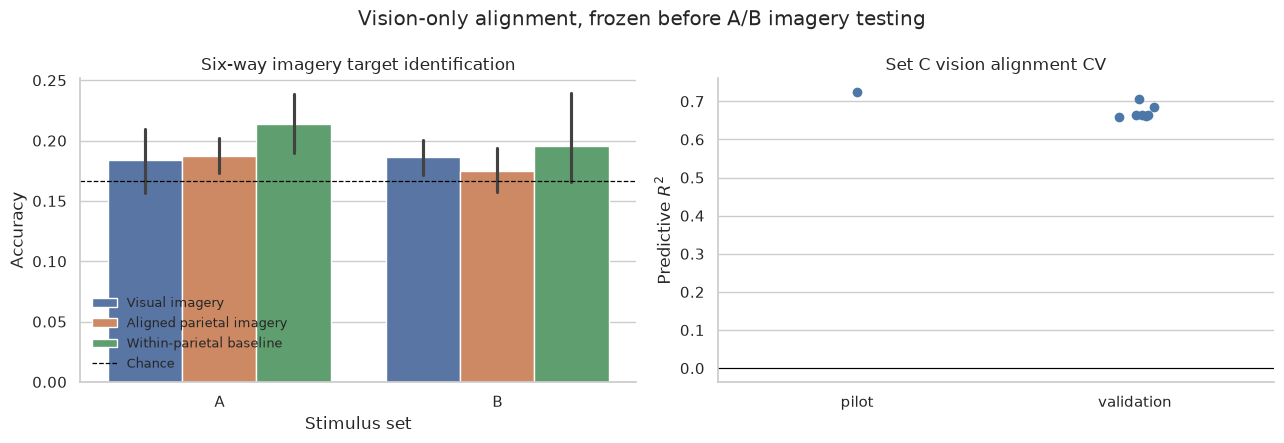

Saved: /home/jovyan/NHprojectNSDimagery/outputs/08_cross_region_transfer/figures/aligned_decoder_accuracy.png


In [6]:
decoder_path = OUTPUT_DIR / 'aligned_decoder_subject_level.csv'
if decoder_path.is_file():
    decoder = pd.read_csv(decoder_path)
    decoder_group = pd.read_csv(OUTPUT_DIR / 'aligned_decoder_group_summary.csv')
    decoder_contrast_group = pd.read_csv(OUTPUT_DIR / 'aligned_decoder_contrast_group.csv')
    selection = pd.read_csv(OUTPUT_DIR / 'alignment_selection.csv')

    display(decoder_group[decoder_group['sample'].eq('subjects_02_08')])
    display(decoder_contrast_group[decoder_contrast_group['sample'].eq('subjects_02_08')])
    display(selection[selection['selected']].sort_values('subject'))

    decoder_labels = {
        'same_visual': 'Visual imagery',
        'aligned_parietal_to_visual': 'Aligned parietal imagery',
        'within_parietal': 'Within-parietal baseline',
    }
    decoder_plot = decoder.copy()
    decoder_plot['decoder_label'] = decoder_plot['decoder'].map(decoder_labels)
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.barplot(
        data=decoder_plot, x='stimulus_set', y='accuracy', hue='decoder_label',
        errorbar=('ci', 95), ax=axes[0],
    )
    axes[0].axhline(1 / 6, color='black', linestyle='--', linewidth=.9, label='Chance')
    axes[0].set(title='Six-way imagery target identification', xlabel='Stimulus set', ylabel='Accuracy')
    axes[0].legend(title='', frameon=False, fontsize=9)
    selected = selection[selection['selected']]
    sns.stripplot(
        data=selected, x='phase', y='mean_cv_r2', order=['pilot', 'validation'],
        color='#4C78A8', jitter=.08, size=7, ax=axes[1],
    )
    axes[1].axhline(0, color='black', linewidth=.8)
    axes[1].set(title='Set C vision alignment CV', xlabel='', ylabel='Predictive $R^2$')
    for axis in axes:
        axis.spines[['top', 'right']].set_visible(False)
    figure.suptitle('Vision-only alignment, frozen before A/B imagery testing')
    figure.tight_layout()
    decoder_figure = FIGURE_DIR / 'aligned_decoder_accuracy.png'
    figure.savefig(decoder_figure, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Saved:', decoder_figure)
else:
    print('Aligned-decoder outputs are absent. Re-run without --skip-aligned-decoder.')

## 5. Interpretation rules

A potentially interesting result requires more than one positive number.

1. The cross-region RDM correlation should be positive and should exceed the same-visual comparison within subject.
2. The pattern should not depend on a single target; inspect `leave_target_min`, `leave_target_median`, and `leave_target_max`.
3. Visual and parietal imagery RDM reliability must be reported. Higher parietal reliability alone can produce an apparent advantage.
4. Standard and crossvalidated RDM results should point in the same direction.
5. For the decoder, the Set C alignment CV score should be above zero, and aligned accuracy should exceed both chance and the shuffled-pairing null.
6. An aligned-parietal advantage over same-visual imagery would be suggestive, not proof of a perception-to-memory transformation.
7. Sets A and B are treated as parallel replications. Set C is used only to learn the alignment and is not an imagery outcome.
8. This analysis is post hoc. Subject-level estimates and uncertainty matter more than a visually striking group average.